In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

train_df = pd.read_csv("data\\train.csv")
val_df = pd.read_csv("data\\validation.csv")

In [2]:
vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])
X_train = vectorizer.transform(train_df['full_name'])
X_val = vectorizer.transform(val_df['full_name'])

y_train = train_df['label']
y_val = val_df['label']

In [3]:
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier # Or RandomForestRegressor
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint

# param_dist = {
#     'n_estimators': randint(10, 500), # Number of trees (integer distribution)
#     'max_depth': randint(1, 20),      # Max depth of each tree (integer distribution)
#     'max_features': ['sqrt', 'log2', None], # Max features to consider (discrete values)
#     'min_samples_split': randint(2, 10), # Min samples to split a node
#     'min_samples_leaf': randint(1, 4), # Min samples required at a leaf node
#     'bootstrap': [True, False] # Whether bootstrap samples are used
# }
    
# # Create a Random Forest classifier instance
# rf = RandomForestClassifier()

# # Initialize RandomizedSearchCV
# rand_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=5, # Number of parameter settings to sample
#     cv=3,       # Number of cross-validation folds
#     scoring='accuracy', # Metric for evaluating performance
#     n_jobs=-1,  # Use all available cores for parallel processing
#     random_state=42 # Set random state for reproducibility
# )
# # Fit the random search object to the data (X_train, y_train)
# rand_search.fit(X_train, y_train)

# print('Best random search hyperparameters are: ' + str(rand_search.best_params_))
# print('Best random search score is: ' + str(rand_search.best_score_))

In [4]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
predicted_y = rfc.predict(X_val)

In [5]:
accuracy = accuracy_score(y_val, predicted_y) * 100

recall = recall_score(y_val, predicted_y) * 100

precision = precision_score(y_val, predicted_y) * 100

f1= f1_score(y_val, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_val, predicted_y))

Accuracy: 87.06772804384705
Recall: 85.36106750392464
Precision: 88.31889550622631
f1_score: 86.81479510377861

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      7682
           1       0.88      0.85      0.87      7644

    accuracy                           0.87     15326
   macro avg       0.87      0.87      0.87     15326
weighted avg       0.87      0.87      0.87     15326



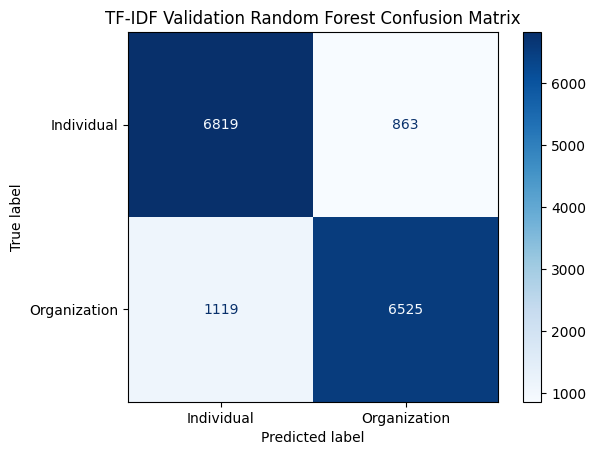

In [6]:
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title('TF-IDF Validation Random Forest Confusion Matrix')
plt.savefig('TF-IDF Validation Random Forest Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [32]:
#test_df = pd.read_csv("data\\test.csv")
test_df = pd.read_csv("data\mi_mn_annotated.csv")
X_test = vectorizer.transform(test_df['merged_full_name']) # 'full_name'
#y_test = test_df['label']

In [36]:
def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'Individual':
        return 1
    else:
        return 0
y_test = np.vectorize(convert_bool)(test_df['transactor_type'])

In [37]:
predicted_y_test = rfc.predict(X_test)
print(classification_report(y_test, predicted_y_test))

              precision    recall  f1-score   support

           0       0.29      0.99      0.45      4924
           1       1.00      0.84      0.91     71780

    accuracy                           0.85     76704
   macro avg       0.65      0.91      0.68     76704
weighted avg       0.95      0.85      0.88     76704



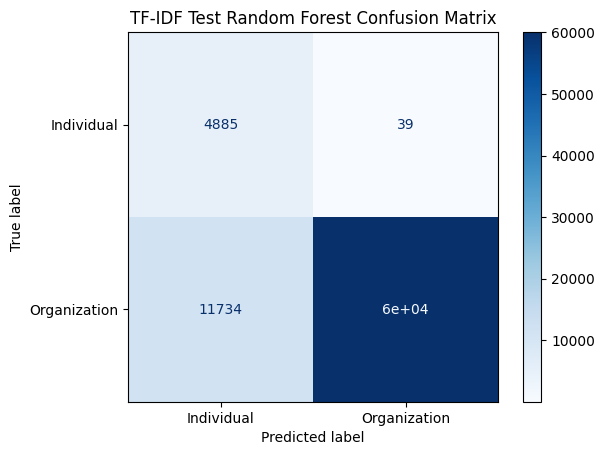

In [39]:
cm = confusion_matrix(y_test, predicted_y_test, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title('TF-IDF Test Random Forest Confusion Matrix')
#plt.savefig('TF-IDF Test Random Forest Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [54]:
misclassified = np.where(y_test != predicted_y_test)[0]
y_test_df = pd.DataFrame(y_test).reset_index().copy()

inverse_names = vectorizer.inverse_transform(X_val)

inverse_names_clean = []
for i in misclassified:
	inverse_names_clean.append(" ".join(list(inverse_names[i])))

print(f"Number of misclassified samples: {len(misclassified)}")
ctr = -1
for i in misclassified:
	ctr+=1
	print(f"ctr: {ctr}")
	print(f"Index: {i}")
	print(f"Full Name: {inverse_names_clean[ctr]}")
	print(f"True Label: {y_test_df.iloc[i]['label']}, Predicted: {predicted_y[i]}")
	print("---")
# Organization = 0
# Individual = 1

IndexError: list index out of range